In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import re
import os
import textwrap
from matplotlib.lines import Line2D

In [14]:
def plot_domain_architecture(df, output_file='protein_map.png', show_labels=True):
    """Plot PFAM domains in ESX1 proteins while labeling IDRs"""
    proteins = df['Protein'].unique()
    num_prots = len(proteins)
    height_multiplier = 1.4 if show_labels else 0.8
    fig, ax = plt.subplots(figsize=(15, num_prots * height_multiplier))
    cmap = plt.get_cmap('Pastel1')
    unique_sigs = df['Signature Accession'].unique()
    color_map = {sig: cmap(i % 9) for i, sig in enumerate(unique_sigs)}
    if show_labels:
        ax.set_ylim(-1.5, num_prots - 0.5)
    else:
        ax.set_ylim(-0.5, num_prots - 0.5)
    ax.invert_yaxis()

    for i, full_id in enumerate(proteins):
        gene_name = full_id.split('|')[1].lower() if '|' in full_id else full_id.lower()
        prot_df = df[df['Protein'] == full_id]
        seq_len = prot_df['Sequence Length'].iloc[0]
        ax.add_patch(patches.Rectangle((0, i - 0.05), seq_len, 0.15,
                                       color='lightgrey', alpha=0.5, zorder=1))

        for idx, row in prot_df.iterrows():
            start, stop = row['Start'], row['Stop']
            sig = row['Signature Accession']
            desc = row['Signature description']
            color = color_map[sig] if show_labels else 'lightgrey'
            width = stop - start
            rect = patches.Rectangle((start, i - 0.1), width, 0.2,
                                     linewidth=1.5, edgecolor='black', facecolor=color, zorder=3)
            ax.add_patch(rect)
            char_width = max(15, int(width / 5))
            wrapped_desc = textwrap.fill(desc, width=char_width)
            label_text = f"{sig}\n{wrapped_desc}"
            if show_labels:
                ax.text(start + width/2, i - 0.2, label_text, ha='center', va='bottom',
                        fontsize=11, fontweight='bold', wrap=True,
                        bbox=dict(facecolor='none', alpha=0.8, edgecolor='none', pad=1))
    if not show_labels:
        legend_elements = [
            patches.Patch(facecolor='lightgray', edgecolor='black',
                          label='Pfam Domain')
        ]
        ax.legend(handles=legend_elements, loc='upper left',
                  bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False, fontsize=14)
    ax.set_yticks(range(num_prots))
    ax.set_yticklabels([p.split('|')[1] if '|' in p else p for p in proteins], fontsize=16, fontweight='bold')
    ax.set_xlabel('Residue Position (aa)', fontsize=16)
    ax.set_xlim(0, df['Sequence Length'].max() * 1.05)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.savefig(output_file, dpi=600, bbox_inches='tight')
    print(f"Diagram saved as {output_file}")
    plt.show()

In [3]:
def parse_fasta(file_path):
    """Parses FASTA and extracts IDs/Sequences."""
    seqs = {}
    with open(file_path, 'r') as f:
        current_id, seq = None, []
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id is not None: 
                    if current_id not in seqs: 
                        seqs[current_id] = []
                    seqs[current_id].append("".join(seq))
                # For Full proteins header == >P9W|espB|Rv3881c -> Rv3881c
                # For IDR header == >Rv3881c_IDR_0 -> Rv3881c
                parts = line[1:].split('|')
                raw_id = parts[-1]
                current_id = raw_id.lower()
                seq = []
            elif line:
                seq.append(line)
        if current_id:
            if current_id not in seqs: 
                seqs[current_id] = []
            seqs[current_id].append("".join(seq))
    return seqs

In [4]:
# Prep for main analysis
## Map Rv IDs to Gene Names
rv_to_gene = {}
with open('full_proteins.fasta', 'r') as f:
    for line in f:
        if line.startswith('>'):
            # Example header: >P9WJD9|espB|Rv3881c
            parts = line[1:].strip().split('|')
            if len(parts) >= 3:
                gene_name = parts[1].lower()
                rv_number = parts[2].lower()
                rv_to_gene[rv_number] = gene_name

## Parse the files
full_proteins = parse_fasta('full_proteins.fasta')

Diagram saved as pfam_without_label.png


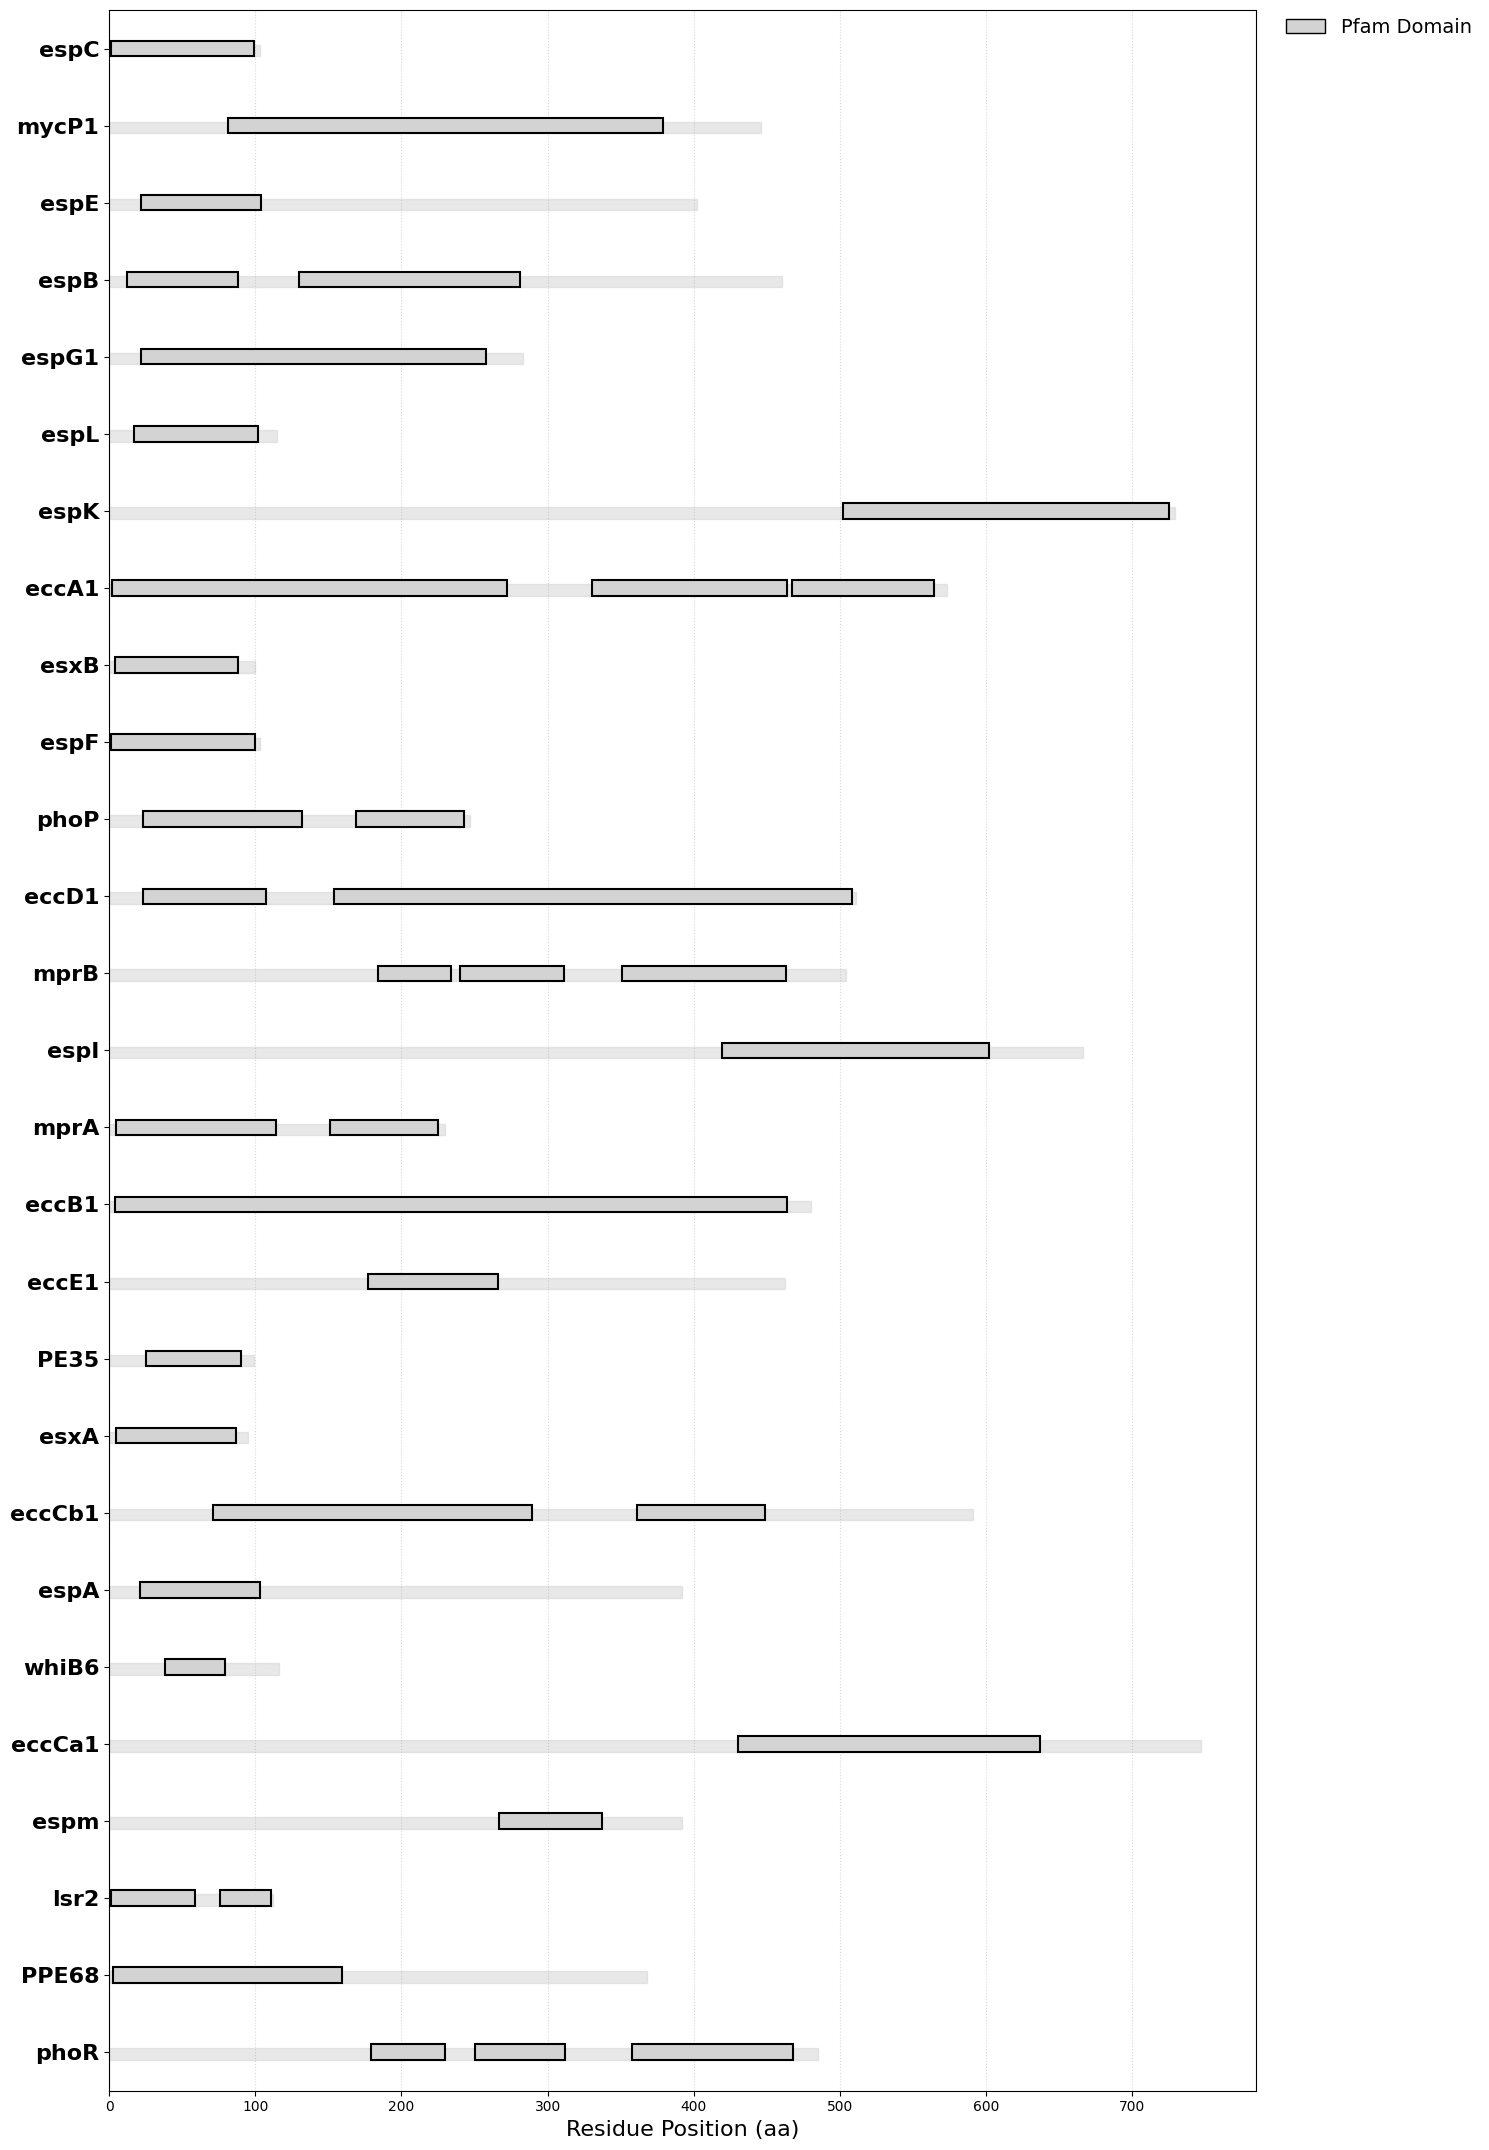

In [10]:
pfam_df = pd.read_excel('pfam_output.xlsx')
plot_domain_architecture(pfam_df, output_file='pfam_without_label.png', show_labels=False)

Diagram saved as pfam_with_label.png


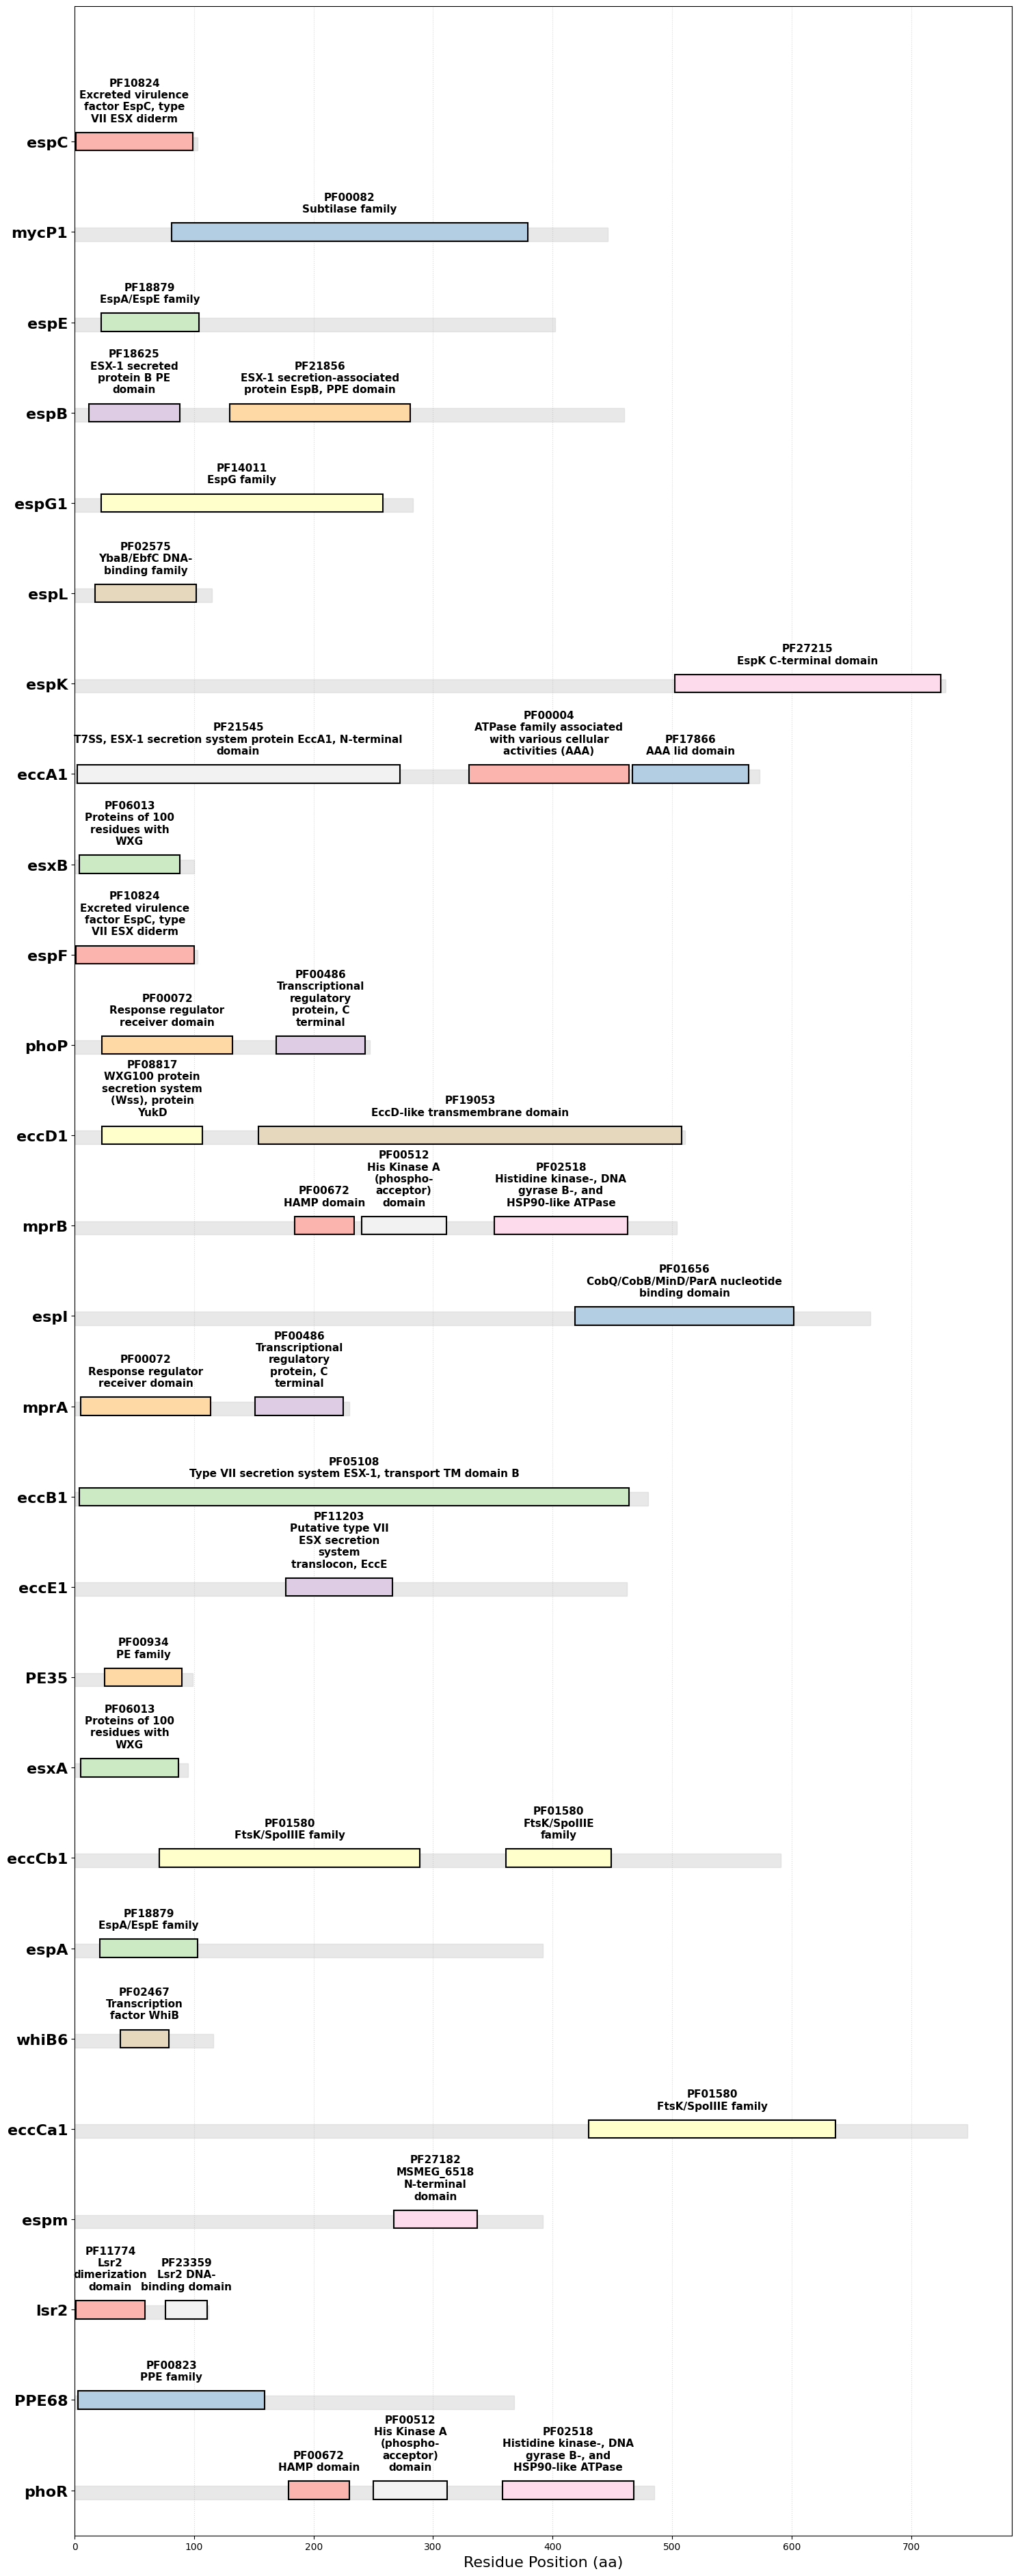

In [15]:
plot_domain_architecture(pfam_df, output_file='pfam_with_label.png', show_labels=True)